In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score,
    RocCurveDisplay
)


In [2]:
url = "https://raw.githubusercontent.com/Darwin2016/dataset2022/main/dataSETS/comprar_alquilar2024.csv"
df = pd.read_csv(url)
df.head()


,ingresos,gastos_comunes,pago_coche,gastos_otros,ahorros,vivienda,estado_civil,hijos,trabajo,comprar
0,6000,1000,0,600,50000,400000,0,2,2,1
1,6745,944,123,429,43240,636897,1,3,6,0
2,6455,1033,98,795,57463,321779,2,1,8,1
3,7098,1278,15,254,54506,660933,0,0,3,0
4,6167,863,223,520,41512,348932,0,0,3,1


In [3]:
df['gastos'] = df['gastos_comunes'] + df['gastos_otros'] + df['pago_coche']
df['financiar'] = df['vivienda'] - df['ahorros']

df = df.drop(['gastos_comunes','gastos_otros','pago_coche'], axis=1)


In [4]:
X = df.drop("comprar", axis=1)
y = df["comprar"]


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = GaussianNB()
model.fit(X_train, y_train)


GaussianNB()

In [6]:
y_pred = model.predict(X_test)


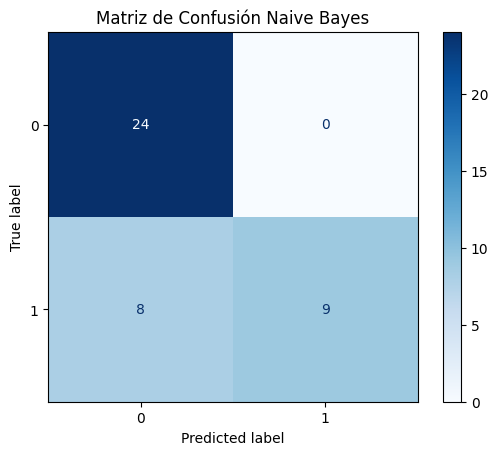

In [7]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Matriz de Confusión Naive Bayes")
plt.show()


In [8]:
y_prob = model.predict_proba(X_test)[:,1]


In [9]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_value = roc_auc_score(y_test, y_prob)

print("AUC:", auc_value)


AUC: 0.8970588235294118


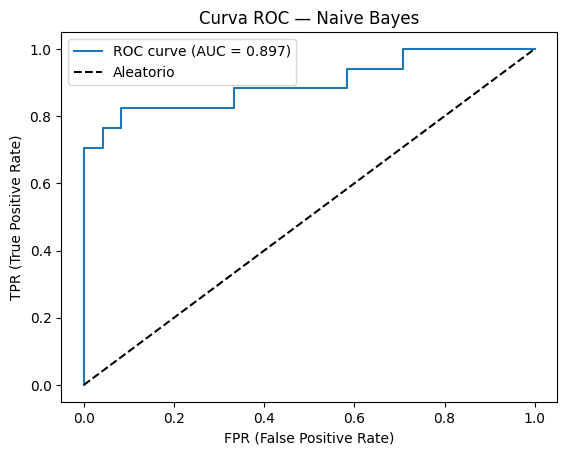

In [10]:
plt.figure()
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {auc_value:.3f})")
plt.plot([0,1], [0,1], 'k--', label="Aleatorio")
plt.xlabel("FPR (False Positive Rate)")
plt.ylabel("TPR (True Positive Rate)")
plt.title("Curva ROC — Naive Bayes")
plt.legend()
plt.show()
